[개념]



1.   평균 이동(Mean Shift)

: 중심을 데이터가 모여 있는 밀도가 가장 높은 곳으로 군집의 중심을 이동시킴.
평균 이동 군집화: 주변 데이터와의 거리 값을 KDE 함수 값으로 입력한 뒤 그 반환 값을 현재 위치에서 업데이트하면서 이동함.
*   핵심 파라미터: bandwidth

```
MeanShift(bandwidth=1)
```
  : 주변 데이터를 어디까지 이웃으로 볼 건지를 의미함.
  (bandwidth가 작으면 가까운 데이터만 봄, 세세하게 나뉘고 군집 개수 많아짐<->  크면 더 넓게 봄, 큰덩어리로 묶여서 군집 개수 감소함)

*   데이터 생성 코드 예시


```
X, y = make_blobs(
    n_samples=200,
    n_features=2,
    centers=3,
    cluster_std=0.7,
    random_state=0
)
```
: n_samples=200: 데이터 200개 생성
  n_features=2 : 변수 2개(x,y)
  centers=3 : 실제 군집 3개
  cluster_std=0.7: 퍼져있는 정도  <br>
  <br>
  <br>
  <br>
  





2.   GMM
: 데이터가 여러개의 정규분포가 섞여서 만들어졌다고 가정하는 군집화 알고리즘, 해당 데이터가 어떤 군집에 속할 확률이 가장 높을지를 계산함.


*   GMM 생성


```
from sklearn.mixture import GaussianMixture
```


*   주요 파라미터
  n_components =3
: 정규분포 군집의 개수
gmm.fit(iris.data)
: 데이터 학습

gmm.predict(iris.data)
: 각 데이터의 군집 변호 예측



```
gmm_cluster_labels = gmm.fit(iris.data).predict(iris.data)
```
*   irisDF['gmm_cluster'] = gmm_cluster_labels
결과 저장






[필사]

In [4]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.7, random_state=0)

meanshift = MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2 3 4 5]


In [5]:
meanshift = MeanShift(bandwidth=1)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


In [6]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print('bandwidth 값:', round(bandwidth,3))

bandwidth 값: 1.816


In [8]:
import pandas as pd

clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target']=y

# estimate_bandwifth()로 최적의 bandwidth 계산
best_bandwidth = estimate_bandwidth(X)

meanshift=MeanShift(bandwidth = best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


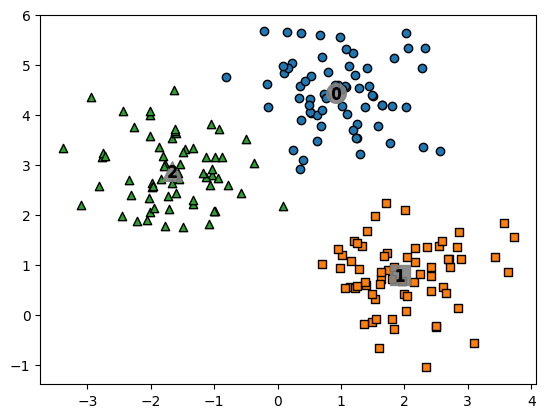

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = clusterDF[clusterDF['meanshift_label']==label]
    center_x_y = centers[label]
    # 군집별로 다른 마커로 산점도 적용
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])
    # 군집별 중심 표현
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
                marker=markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)
plt.show()



In [12]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


In [13]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 좀 더 편리한 데이터 Handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target'] = iris.target

In [16]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components = 3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

# 군집화 결과를 irisDF의 'gmm_cluster' 칼럼명으로 저장
irisDF['gmm_cluster'] = gmm_cluster_labels
irisDF['target'] = iris.target

# target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인.
iris_result = irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


In [18]:
kmeans =  KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisDF['kmeans_cluster'] = kmeans_cluster_labels
iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

%matplotlib inline


def visualize_cluster_plot(cluster_result=None, dataframe=None,
                           label_name='target', iscenter=True):

    if dataframe is None:
        print("Error: DataFrame is required.")
        return

    unique_labels = np.unique(dataframe[label_name])

    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for label in unique_labels:

        label_cluster = dataframe[dataframe[label_name] == label]

        plt.scatter(
            x=label_cluster['ftr1'],
            y=label_cluster['ftr2'],
            edgecolor='k',
            marker=markers[label % len(markers)]
        )

        if (iscenter and cluster_result is not None and
                hasattr(cluster_result, 'cluster_centers_')):

            center_x_y = cluster_result.cluster_centers_[label]

            plt.scatter(
                x=center_x_y[0],
                y=center_x_y[1],
                s=200,
                color='gray',
                alpha=0.9,
                marker=markers[label % len(markers)]
            )

            plt.scatter(
                x=center_x_y[0],
                y=center_x_y[1],
                s=70,
                color='k',
                edgecolor='k',
                marker='$%d$' % label
            )

    plt.show()

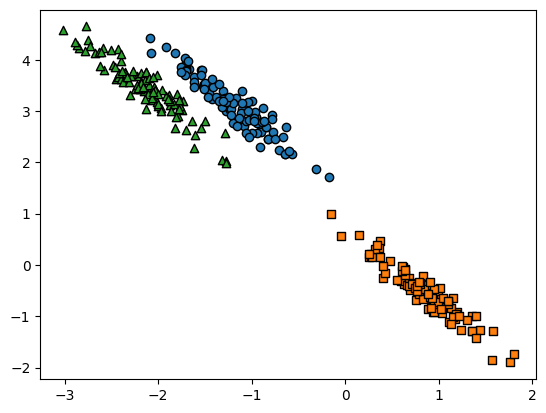

In [21]:
from sklearn.datasets import make_blobs

# make_blobs()로 300개의 데이터 세트, 3개의 군집 세트, cluster_std =0.5를 만듦.
X, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0)

# 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환함.
transformation = [[0.6084549, -0.63667641], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)
# feature 데이터 세트와 make_blobs()의 y 결괏값을 DataFrame으로 저장
clusterDF = pd.DataFrame(data=X_aniso, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y
# 생성된 데이터 세트를 target별로 다른 마커로 표시해 시각화함
visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

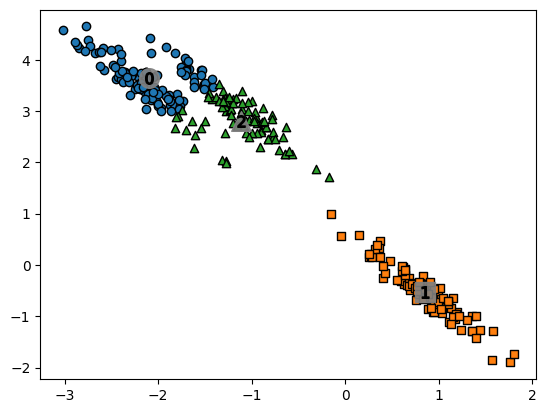

In [22]:
# 3개의 군집 기반 Kmeans를 X_aniso 데이터 세트에 적용
kmeans =KMeans(3, random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)
clusterDF['kmeans_label'] = kmeans_label

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter=True)

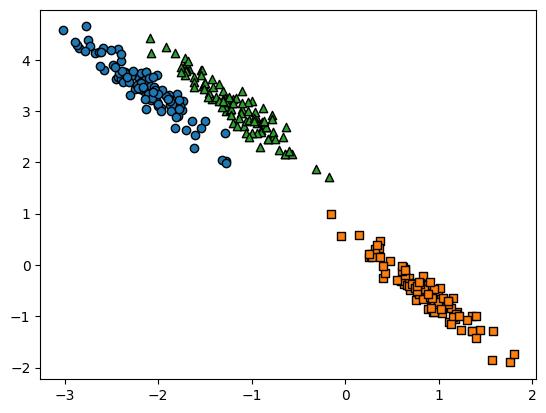

In [24]:
# 3개의 n_components 기반 GMM을 X_aniso 데이터 세트에 적용
gmm = GaussianMixture(n_components=3, random_state=0)
gmm_label =gmm.fit(X_aniso).predict(X_aniso)
clusterDF['gmm_label'] = gmm_label

# GaussianMixture는 cluster_centers_ 속성이 없으므로 iscenter를 False로 설정.
visualize_cluster_plot(gmm, clusterDF, 'gmm_label', iscenter=False)

In [25]:
print('### KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())
print('\n### Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64
